# EDA - Use Case Data Review, Combine & Clean

**ELI5:** `data/raw/` has 6 files, one per research "use case" (e.g. *carbon capture*,
*named entity recognition*). Each is a JSONL export from `academic_research_agent`: one
line per paper (title, abstract, metadata, an analyst's `triage_label`, a precomputed
embedding), plus a `_meta` header line. Before doing any cleaning or modelling, this
notebook answers two questions per file:

1. **Structure** — same columns everywhere? Same embedding model? Where are the nulls,
   and do they mean "never found out" (see `CONTRIBUTING.md`: NULL ≠ 0) or something else?
2. **Volume** — how many papers, how are they labelled, how skewed are things like
   citation counts or publication year?

This is descriptive only — no modelling, no cleaning decisions made here.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("../../data/raw")

# Colors follow the project's own convention (scripts/compare_embeddings.py LABEL_COLORS)
# for triage labels, so this notebook doesn't invent a second color language for the same
# categories. The use-case identity colors are a separate fixed set, chosen to avoid the
# red/green/purple already reserved for label sentiment.
LABEL_COLORS = {"positive": "#2ca02c", "negative": "#d62728", "pass": "#9467bd"}
UNLABELLED_COLOR = "#c7c7c7"
USE_CASE_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e87ba4", "#eb6834"]
SEQUENTIAL = "#2a78d6"
SEQUENTIAL_ALT = "#1baf7a"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

## Load every export

Each file is JSONL with one header line (`{"_meta": {...}}`) followed by one JSON object
per paper. `embedding_utils.load_export` only handles `.parquet`/`.csv` today, so this
notebook uses its own small loader — that's fine for exploratory JSONL reading; a JSONL
export loader belongs in `embedding_utils.py` only once a script (not a one-off notebook)
actually needs to consume these files.

In [2]:
def load_jsonl_export(path: Path) -> tuple[dict, pd.DataFrame]:
    """Split an academic_research_agent JSONL export into its (meta, records) parts.
    Identifies the meta line by content (a lone "_meta" key), not by position."""
    meta = {}
    rows = []
    with open(path) as fh:
        for line in fh:
            d = json.loads(line)
            if set(d.keys()) == {"_meta"}:
                meta = d["_meta"]
            else:
                rows.append(d)
    return meta, pd.DataFrame(rows)


files = sorted(DATA_DIR.glob("*.jsonl"))
datasets = {}
for f in files:
    meta, df = load_jsonl_export(f)
    datasets[meta.get("use_case", f.stem)] = {
        "file": f.name,
        "file_size_kb": f.stat().st_size / 1024,
        "meta": meta,
        "df": df,
    }

use_cases = list(datasets.keys())
print(f"Loaded {len(datasets)} use cases:")
for uc in use_cases:
    n_papers = len(datasets[uc]["df"])
    fname = datasets[uc]["file"]
    print(f"  - {uc}  ({n_papers} papers, {fname})")

Loaded 6 use cases:
  - Carbon Capture  (323 papers, carbon_capture.jsonl)
  - Low-carbon cement binders  (690 papers, cement_binders.jsonl)
  - Named Entity Recognition  (541 papers, ner.jsonl)
  - High quality microbial and fungal community in Soil  (602 papers, soil_microbiome.jsonl)
  - solar cells for low earth orbit satellites  (427 papers, solar_leo.jsonl)
  - Predicting Technology Developments  (290 papers, tech_forecasting.jsonl)


## Data dictionary

One row per column (every column except `embedding` — a 384-float vector doesn't have a
useful range/mean/mode/median). For each column below:

- **numeric columns** (`year`, `citation_count`, `relevance_score`) get a real
  **range (min, max), mean, median, mode** — computed per use case AND for the
  **combined set** (all 6 files concatenated, tagged with a `use_case` column).
- **low-cardinality categorical columns** (`triage_label`, `review_label`, `language`,
  `sources`, `venue`, `abstract_source`) get **mode** (+ its share of non-null rows) and
  `n_unique` instead — a mean/median of a label string isn't meaningful, so reporting it
  would just be noise dressed up as a statistic.
- **identifiers / free text** (`id`, `title`, `authors`, `doi`, `url`, `abstract`) get
  non-null count and uniqueness instead — same reasoning, one step further (most values
  here are close to unique by construction).

This is the "label which critic is speaking" convention applied to summary statistics
themselves: a numeric mean is a hard computation, but forcing one onto a DOI string
would just be a fabricated number wearing a real one's clothes.

In [3]:
combined_df = pd.concat(
    [d["df"].assign(use_case=uc) for uc, d in datasets.items()], ignore_index=True
)
group_order = sorted(datasets, key=lambda uc: len(datasets[uc]["df"]), reverse=True) + ["COMBINED (all 6)"]

# A concrete reason the "combined set" needs care, not just a concat: ids are assigned
# per export, not globally, so the same id can legitimately mean two different papers
# once use cases are pooled.
n_id_collisions = combined_df["id"].duplicated().sum()
print(f"combined_df: {len(combined_df)} rows across {combined_df['use_case'].nunique()} use cases")
print(f"id collisions once pooled: {n_id_collisions} rows share an id with a row from a "
      f"DIFFERENT use case (id is only unique WITHIN one file's export).")

combined_df: 2873 rows across 6 use cases
id collisions once pooled: 587 rows share an id with a row from a DIFFERENT use case (id is only unique WITHIN one file's export).


In [4]:
DESCRIPTIONS = {
    "id": "Row identifier assigned by the export. Unique WITHIN a use case, NOT globally (see check above).",
    "title": "Paper title.",
    "authors": "Author list as one comma-separated string, as returned by the source metadata provider.",
    "year": "Publication year (or expected year, for in-press records).",
    "venue": "Journal / conference / publisher name, as returned by the source.",
    "doi": "Digital Object Identifier — the closest thing to a stable real-world key for a paper.",
    "url": "Link to the paper (publisher page, DOI resolver, or source API record).",
    "sources": 'Which metadata provider(s) matched this paper; comma-joined when more than one agreed (e.g. "crossref, openalex").',
    "language": "Language code of the title/abstract, as detected by the source.",
    "citation_count": "Citation count at export time. NULL = the source never returned a count - NOT the same as 0 citations.",
    "triage_label": "Analyst's first-pass judgement: positive / negative / pass. NULL = never triaged.",
    "review_label": "Analyst's second-pass QC judgement. Almost entirely NULL across all 6 exports.",
    "relevance_score": "The agent's own ranking score for this paper against the use case.",
    "abstract": "Paper abstract text. Can be empty (0 words) for title-only records.",
    "abstract_source": "Intended to record where the abstract text came from. Always null where the column exists at all.",
}

NUMERIC_COLS = ["year", "citation_count", "relevance_score"]
CATEGORICAL_COLS = ["triage_label", "review_label", "language", "sources", "venue", "abstract_source"]
IDENTIFIER_COLS = ["id", "title", "authors", "doi", "url", "abstract"]

stat_type = {c: "numeric" for c in NUMERIC_COLS}
stat_type.update({c: "categorical (mode)" for c in CATEGORICAL_COLS})
stat_type.update({c: "identifier / free text" for c in IDENTIFIER_COLS})

data_dictionary = pd.DataFrame([
    {"column": col, "dtype": str(combined_df[col].dtype), "stat_type": stat_type[col], "description": desc}
    for col, desc in DESCRIPTIONS.items()
])
data_dictionary

,column,dtype,stat_type,description
0,id,int64,identifier / free text,Row identifier assigned by the export. Unique ...
1,title,str,identifier / free text,Paper title.
2,authors,str,identifier / free text,"Author list as one comma-separated string, as ..."
3,year,float64,numeric,"Publication year (or expected year, for in-pre..."
4,venue,str,categorical (mode),"Journal / conference / publisher name, as retu..."
5,doi,str,identifier / free text,Digital Object Identifier — the closest thing ...
6,url,str,identifier / free text,"Link to the paper (publisher page, DOI resolve..."
7,sources,str,categorical (mode),Which metadata provider(s) matched this paper;...
8,language,str,categorical (mode),"Language code of the title/abstract, as detect..."
9,citation_count,float64,numeric,Citation count at export time. NULL = the sour...


### Export metadata — one row per use case

Every export's `_meta` line records the embedding model, its vector dimension, and when
it was exported — combined below into a single table, one row per use case, for a
side-by-side comparison. Header metadata only, no embedding vectors: if every use case
shares the same `embed_model`/`dim`, the 6 corpora's per-paper embeddings are directly
comparable/poolable later without re-embedding.

In [5]:
meta_table = pd.DataFrame([
    {
        "use_case": uc,
        "file": d["file"],
        "n_papers": len(d["df"]),
        "file_size_kb": round(d["file_size_kb"], 1),
        "embed_model": d["meta"].get("embed_model", "").split("@")[0],
        "dim": d["meta"].get("dim"),
        "exported_at": d["meta"].get("exported_at"),
        "app_version": d["meta"].get("app_version"),
    }
    for uc, d in datasets.items()
]).sort_values("n_papers", ascending=False).reset_index(drop=True)
meta_table

,use_case,file,n_papers,file_size_kb,embed_model,dim,exported_at,app_version
0,Low-carbon cement binders,cement_binders.jsonl,690,6801.2,sentence-transformers/paraphrase-multilingual-...,384,2026-08-03T10:02:16+00:00,1.2.0.dev0
1,High quality microbial and fungal community in...,soil_microbiome.jsonl,602,5700.8,sentence-transformers/paraphrase-multilingual-...,384,2026-07-29T07:16:31+00:00,1.2.0.dev0
2,Named Entity Recognition,ner.jsonl,541,5276.8,sentence-transformers/paraphrase-multilingual-...,384,2026-08-03T10:02:09+00:00,1.2.0.dev0
3,solar cells for low earth orbit satellites,solar_leo.jsonl,427,4100.9,sentence-transformers/paraphrase-multilingual-...,384,2026-08-03T12:55:14+00:00,1.2.0.dev0
4,Carbon Capture,carbon_capture.jsonl,323,3169.6,sentence-transformers/paraphrase-multilingual-...,384,2026-08-03T10:01:06+00:00,1.2.0.dev0
5,Predicting Technology Developments,tech_forecasting.jsonl,290,2819.1,sentence-transformers/paraphrase-multilingual-...,384,2026-08-03T10:01:37+00:00,1.2.0.dev0


In [6]:
same_model = meta_table["embed_model"].nunique() == 1
same_dim = meta_table["dim"].nunique() == 1
print(f"Same embed_model across all 6 exports: {same_model} ({meta_table['embed_model'].iloc[0]})")
print(f"Same embedding dim across all 6 exports: {same_dim} ({meta_table['dim'].iloc[0]})")

Same embed_model across all 6 exports: True (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
Same embedding dim across all 6 exports: True (384)


### 1c. Null structure — and where NULL ≠ 0 actually shows up

Per `CONTRIBUTING.md`: a null must mean "never found out", not get collapsed into 0. This
heatmap shows null **rate** per column per use case; the two columns below the heatmap
double-check that citation_count's nulls are genuinely distinct from real zero-citation
papers (if they weren't, this convention would be moot for this field).

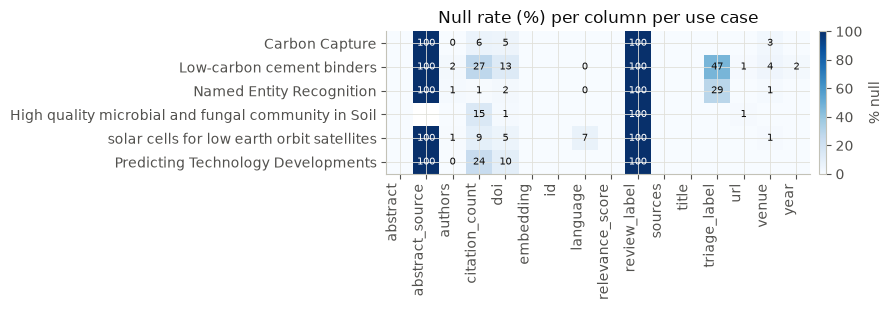

In [7]:
all_columns = sorted(set().union(*(d["df"].columns for d in datasets.values())))
null_rates = pd.DataFrame(
    {uc: d["df"].isna().mean() for uc, d in datasets.items()}
).reindex(all_columns).T * 100

fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(null_rates.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(all_columns)), all_columns, rotation=90, ha="right")
ax.set_yticks(range(len(null_rates.index)), null_rates.index)
for i in range(null_rates.shape[0]):
    for j in range(null_rates.shape[1]):
        v = null_rates.values[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    fontsize=7, color="white" if v > 55 else "#0b0b0b")
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("% null", color="#52514e")
ax.set_title("Null rate (%) per column per use case")
fig.tight_layout()
plt.show()

In [8]:
print("citation_count: null vs. genuine zero (these must stay distinct, not both -> 0)")
for uc, d in datasets.items():
    df = d["df"]
    n_null = df["citation_count"].isna().sum()
    n_zero = (df["citation_count"] == 0).sum()
    print(f"  {uc:45s} null={n_null:3d}  zero={n_zero:3d}  (of {len(df)})")

citation_count: null vs. genuine zero (these must stay distinct, not both -> 0)
  Carbon Capture                                null= 19  zero=107  (of 323)
  Low-carbon cement binders                     null=189  zero=212  (of 690)
  Named Entity Recognition                      null=  4  zero=229  (of 541)
  High quality microbial and fungal community in Soil null= 88  zero=177  (of 602)
  solar cells for low earth orbit satellites    null= 40  zero=133  (of 427)
  Predicting Technology Developments            null= 70  zero=122  (of 290)


**Finding:** `citation_count` nulls and zeros both occur, in different proportions
per use case (e.g. cement-binders: 189 "never looked up" vs. 212 genuine "zero
citations" — almost matched in size, so collapsing them would materially change what a
feature derived from citation_count means). `review_label` is null in effectively every
row across all 6 files (a single `soft_pos` exception in cement-binders) — the review
(second-pass QC) stage has barely started on any of these corpora yet, which matters for
anyone tempted to model against `review_label` right now. `triage_label` nulls are also
not the same as the `'pass'` label value — a null triage_label means "never triaged",
while `'pass'` is an analyst's explicit judgement call. 2 of the 6 files (cement-binders, NER)
currently mix both.

### 1d. Which papers are missing key metadata

The null-rate heatmap above shows *how much* is missing per column; before deciding
what to do about it, it helps to see *which actual papers* are behind those numbers.
One table per field, built on the pooled `combined_df` so a paper missing more than one
field only needs looking up once (via `use_case` + `id`, since `id` alone isn't a
global key — see the data dictionary above).

In [9]:
from IPython.display import display

NULL_CHECK_COLS = ["language", "authors", "title", "year", "venue", "url", "doi"]

def null_review_table(df: pd.DataFrame, col: str, abstract_chars: int = 160) -> pd.DataFrame:
    """Papers missing `col`, for manual review — title/abstract identify the paper,
    use_case/id trace it back to its source export."""
    subset = df[df[col].isna()]
    abstracts = subset["abstract"].fillna("")
    snippet = abstracts.where(
        abstracts.str.len() <= abstract_chars, abstracts.str.slice(0, abstract_chars) + "…"
    )
    return pd.DataFrame({
        "use_case": subset["use_case"].to_numpy(),
        "id": subset["id"].to_numpy(),
        "title": subset["title"].to_numpy(),
        "abstract_snippet": snippet.to_numpy(),
    }).reset_index(drop=True)

for col in NULL_CHECK_COLS:
    table = null_review_table(combined_df, col)
    print(f"--- {col}: {len(table)} papers missing this field ---")
    display(table)

--- language: 32 papers missing this field ---


,use_case,id,title,abstract_snippet
0,Low-carbon cement binders,442,Alternative Binder,
1,Named Entity Recognition,2813,APRESENTAÇÃO,A 78-year-old patient presented with shortness...
2,solar cells for low earth orbit satellites,1853,Organometal halide perovskite solar cells: deg...,What are the bottlenecks for organometal halid...
3,solar cells for low earth orbit satellites,1846,"Insight into Evolution, Processing and Perform...",AbstractThe structural characterization correl...
4,solar cells for low earth orbit satellites,1858,Solvent engineering towards controlled grain g...,The formation of intermediate phase of (CH\n ...
5,solar cells for low earth orbit satellites,1847,Enhancing Thermal Stability and Lifetime of So...,
6,solar cells for low earth orbit satellites,1856,"A low-cost, high-efficiency solar cell based o...",THE large-scale use of photovoltaic devices fo...
7,solar cells for low earth orbit satellites,1855,Metal halide perovskite tandem and multiple-ju...,
8,solar cells for low earth orbit satellites,1850,Highly-efficient dye-sensitized solar cells wi...,A collaborative sensitization by silyl-anchor ...
9,solar cells for low earth orbit satellites,1860,Microporous La0.8Sr0.2MnO3 perovskite nanorods...,


--- authors: 26 papers missing this field ---


,use_case,id,title,abstract_snippet
0,Carbon Capture,1194,Energy-efficient Solvent Properties for the Po...,Abstract Heat consumption is a major concern f...
1,Low-carbon cement binders,153,Unveiling the Carbon Footprint Reduction Poten...,This study evaluated the effects of CO2 seques...
2,Low-carbon cement binders,684,Pairing Chemical Activation and Carbonation of...,CO2 capture and mineralization within the conc...
3,Low-carbon cement binders,647,Carbon dioxide capture. Overview of carbon dio...,13.020.40
4,Low-carbon cement binders,689,Study on the durability of alkali-activated sl...,To expand the application scope of slag-based ...
5,Low-carbon cement binders,140,Experimental Study on a Low-Carbon Pervious Co...,The uncontrolled urban development of the last...
6,Low-carbon cement binders,648,"Carbon Dioxide Capture, Utilization and Storag...","This Special Issue on ""Carbon Dioxide Capture,..."
7,Low-carbon cement binders,404,A Pilot-Scale Field Study: In Situ Treatment o...,A combined\napproach involving microbial bioau...
8,Low-carbon cement binders,63,Structural Performance of Fly Ash–GGBS Based G...,"By drastically lowering carbon emissions, geop..."
9,Low-carbon cement binders,532,Limestone Calcined Clay Cement for Three-Dimen...,First Name is required invalid characters Last...


--- title: 0 papers missing this field ---


...

,use_case,id,title,abstract_snippet
0,Carbon Capture,1191,Advancements in the Treatment of Amine-Rich Wa...,Carbon capture and storage (CCS) plants play a...
1,Carbon Capture,1499,Experimental Evaluation of Electrochemically M...,"In the present study, the integration of elect..."
2,Carbon Capture,1629,Multiple-Amine Functionalized Γ–Al2o3 for Post...,Highly-efficient and cost-effective adsorbents...
3,Carbon Capture,3562,Rational Design of Aqueous Tertiary Amine Solv...,Several tertiary amine solutions with differen...
4,Carbon Capture,3507,Thermophysical properties of aqueous amines so...,"El cambio climático, impulsado por las emision..."
5,Carbon Capture,3470,Response Surface Optimization of Non-Aqueous H...,The CO2 absorption–desorption performances of ...
6,Carbon Capture,3357,Absorption-based carbon capture energy penalty...,peer reviewed
7,Carbon Capture,1500,Optimization of the electrochemically mediated...,The electrochemically mediated amine regenerat...
8,Carbon Capture,3500,Amine-Appended Metal–Organic Frameworks as Swi...,The goal of this final project report is to co...
9,Low-carbon cement binders,153,Unveiling the Carbon Footprint Reduction Poten...,This study evaluated the effects of CO2 seques...


--- url: 14 papers missing this field ---


,use_case,id,title,abstract_snippet
0,Low-carbon cement binders,379,CO2–Binder Reaction Mechanisms in Geopolymer W...,API Classes of cement are susceptible to three...
1,Low-carbon cement binders,424,Alkali-Activated Polymers for Grouting: A Revi...,Under dual challenges of global infrastructure...
2,Low-carbon cement binders,526,Effect of calcined clay and marble dust powder...,"In the last decade, there has been an increase..."
3,Low-carbon cement binders,118,Valorization of Volcanic Ash and Stainless Ste...,The high environmental impact associated with ...
4,Low-carbon cement binders,627,Role of Reactive Silica Addition in Enhancing ...,This study examined the geopolymerization beha...
5,Low-carbon cement binders,318,Optimization and Performance Evaluation of Mul...,"The use of a multi-component binder (MCB), con..."
6,Low-carbon cement binders,422,Effect of Waste Composite Plate Powders on the...,This study investigates the effects of artific...
7,High quality microbial and fungal community in...,253,Deciphering Conserved Rhizosphere Metabolite–M...,Drought stress is a major threat to global foo...
8,High quality microbial and fungal community in...,482,Harnessing Plant–Microorganism Interactions to...,
9,High quality microbial and fungal community in...,364,Navigating Climate Change: Exploring the Dynam...,Understanding the intricate interplay between ...


--- doi: 176 papers missing this field ---


,use_case,id,title,abstract_snippet
0,Carbon Capture,1182,SAGE-Amine: Generative Amine Design with Multi...,Efficient CO2 capture is vital for mitigating ...
1,Carbon Capture,1246,Design of Carbon Capture Processes Under Part-...,Solvent-based carbon capture can reduce CO2 em...
2,Carbon Capture,1276,Post-combustion CO2 capture by absorption-rege...,"The implementation of Carbon Capture, Utilizat..."
3,Carbon Capture,1248,Advancing Carbon Capture using AI: Design of p...,This study focuses on membrane-based systems f...
4,Carbon Capture,1245,A commercial pathway for evaluating the perfor...,A Thesis Submitted to the Faculty of Graduate ...
...,...,...,...,...
171,Predicting Technology Developments,3223,KG20C & KG20C-QA: Scholarly Knowledge Graph Be...,"In this paper, we present KG20C and KG20C-QA, ..."
172,Predicting Technology Developments,3145,Neighbourhood Transformer: Switchable Attentio...,Graph neural networks (GNNs) have been widely ...
173,Predicting Technology Developments,1012,Phosphatase-Substrate Prediction using Heterog...,Background: Phosphatase-substrate interactions...
174,Predicting Technology Developments,1014,DiffGraph: Heterogeneous Graph Diffusion Model,Recent advances in Graph Neural Networks (GNNs...


**Finding:** these tables are for manual review, not an automated fix — some gaps
(e.g. `venue` for a preprint, `doi` for an unpublished record) may be genuinely
unresolvable rather than a scraping failure. `title` should always show 0 rows here;
if it ever doesn't, something upstream in the export broke a basic invariant (every
other check in this notebook assumes a title exists) and needs investigating before
anything else here is trusted.

### 2b. Label distribution — volume AND structure at once

`triage_label` is the key column for Week 3 modelling. Colors reuse the project's
existing label convention (`compare_embeddings.py:LABEL_COLORS`) so this chart reads
consistently with the rest of the repo. This is a part-to-whole comparison across
categories → stacked bar, with the null ("never triaged") slice kept visually distinct
from the `'pass'` slice.

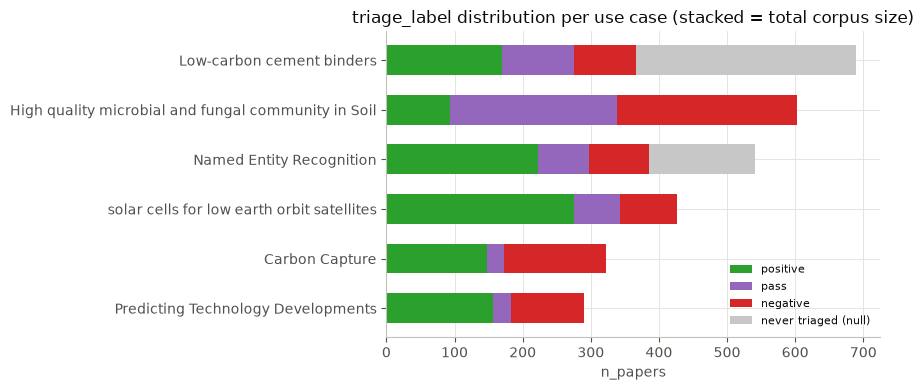

In [10]:
label_order = ["positive", "pass", "negative", None]
legend_labels = {"positive": "positive", "pass": "pass", "negative": "negative", None: "never triaged (null)"}
colors = {**LABEL_COLORS, None: UNLABELLED_COLOR}

counts = pd.DataFrame({
    uc: d["df"]["triage_label"].value_counts(dropna=False).reindex(label_order, fill_value=0)
    for uc, d in datasets.items()
}).T.reindex(sorted(datasets, key=lambda uc: len(datasets[uc]["df"])))

fig, ax = plt.subplots(figsize=(9, 4))
left = np.zeros(len(counts))
for lab in label_order:
    ax.barh(counts.index, counts[lab], left=left, color=colors[lab], label=legend_labels[lab], height=0.6)
    left += counts[lab].to_numpy()
ax.set_xlabel("n_papers")
ax.set_title("triage_label distribution per use case (stacked = total corpus size)")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

### 2c. Publication year — small multiples

Six overlapping histograms on one axes would be unreadable, so this uses small
multiples (one panel per use case, shared x-axis) instead of forcing a 6-color
categorical legend onto a distribution chart.

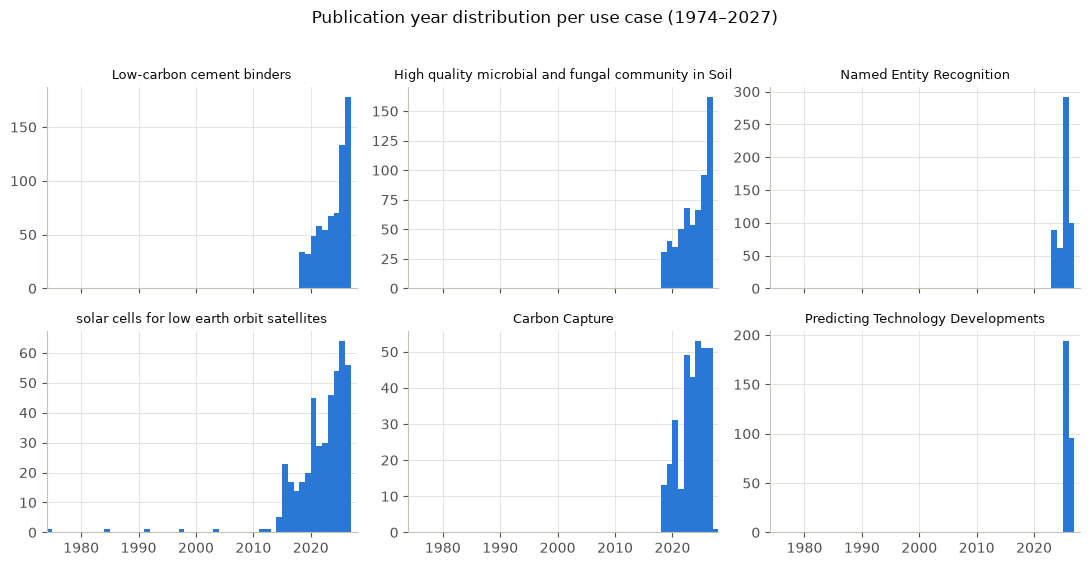

In [11]:
all_years = pd.concat([d["df"]["year"] for d in datasets.values()]).dropna()
year_min, year_max = int(all_years.min()), int(all_years.max())

fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharex=True, sharey=False)
for ax, uc in zip(axes.flat, sorted(datasets, key=lambda uc: len(datasets[uc]["df"]), reverse=True)):
    years = datasets[uc]["df"]["year"].dropna()
    ax.hist(years, bins=range(year_min, year_max + 2), color=SEQUENTIAL)
    ax.set_title(uc, fontsize=9)
    ax.set_xlim(year_min, year_max + 1)
fig.suptitle(f"Publication year distribution per use case ({year_min}–{year_max})", y=1.02)
fig.tight_layout()
plt.show()

**Finding:** ranges differ sharply by field maturity/search recency, not just
corpus size — NER and predicting-technology-developments are both concentrated in
2023-2026 (fast-moving/recent search), while solar-cells spans back to 1974 (a much
older literature) and cement-binders/soil each go back to 2018. A couple of rows carry
a `year` of 2027 (cement-binders) — in-press/forthcoming papers, not a data error, but
worth knowing before any "recency" feature assumes `year <= current_year`.

### 2d. Citation count and abstract length — one boxplot each, log-scaled

Both are heavy-tailed counts, so this uses a log y-axis; still one hue (this is
magnitude-across-categories, not a set of distinct series), consistent with the bar
charts above.

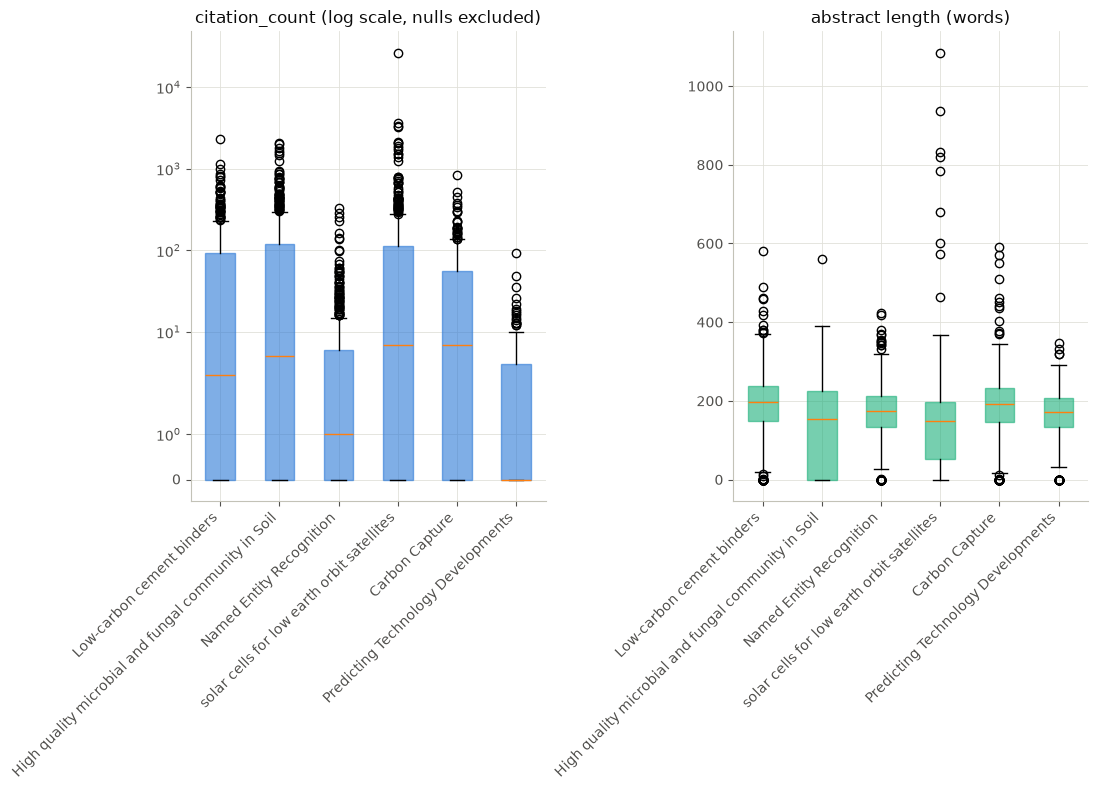

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 8))

order_names = sorted(datasets, key=lambda uc: len(datasets[uc]["df"]), reverse=True)
cite_data = [datasets[uc]["df"]["citation_count"].dropna() for uc in order_names]
bp = axes[0].boxplot(cite_data, tick_labels=order_names, patch_artist=True, showfliers=True)
for box in bp["boxes"]:
    box.set(facecolor=SEQUENTIAL, alpha=0.6, edgecolor=SEQUENTIAL)
axes[0].set_yscale("symlog")
axes[0].set_title("citation_count (log scale, nulls excluded)")
axes[0].tick_params(axis="x", rotation=45)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

abs_len_data = [datasets[uc]["df"]["abstract"].str.split().str.len() for uc in order_names]
bp2 = axes[1].boxplot(abs_len_data, tick_labels=order_names, patch_artist=True, showfliers=True)
for box in bp2["boxes"]:
    box.set(facecolor=SEQUENTIAL_ALT, alpha=0.6, edgecolor=SEQUENTIAL_ALT)
axes[1].set_title("abstract length (words)")
axes[1].tick_params(axis="x", rotation=45)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

fig.tight_layout()
plt.show()

In [13]:
empty_abstracts = {uc: int((d["df"]["abstract"].str.split().str.len() == 0).sum()) for uc, d in datasets.items()}
print("Papers with a 0-word abstract (title-only rows that still passed the empty-row filter):")
for uc, n in empty_abstracts.items():
    print(f"  {uc:45s} {n}")

Papers with a 0-word abstract (title-only rows that still passed the empty-row filter):
  Carbon Capture                                53
  Low-carbon cement binders                     80
  Named Entity Recognition                      57
  High quality microbial and fungal community in Soil 260
  solar cells for low earth orbit satellites    76
  Predicting Technology Developments            45


**Finding:** citation counts are similarly right-skewed everywhere (expected —
citations are always heavy-tailed), so this isn't very discriminating between use
cases. Abstract length medians cluster around 150-200 words across all 6, but every
file has at least one paper with a **0-word abstract** — title-only records with an empty abstract string. (This notebook reads the raw export as-is — it doesn't call `embedding_utils.drop_empty_rows`, which is specific to the two analysis scripts.) Solar-cells has the longest tail
(max 1085 words) and 30 rows with a missing `language`, both consistent with it being
the file with the widest year range and the messiest source mix (see below).

### 2e. Source mix, language diversity, and duplicate DOIs

Not every comparison needs a chart — this is a compact table instead of forcing a 6th
or 7th figure onto data that's really just a handful of headline numbers per use case.

In [14]:
summary_rows = []
for uc, d in datasets.items():
    df = d["df"]
    summary_rows.append({
        "use_case": uc,
        "n_papers": len(df),
        "n_unique_source_combos": df["sources"].nunique(),
        "pct_non_english": round((df["language"] != "en").mean() * 100, 1),
        "n_null_language": int(df["language"].isna().sum()),
        "n_null_doi": int(df["doi"].isna().sum()),
        # .duplicated() treats every null as equal to every other null, so calling it
        # directly on a nullable identifier column overstates "duplicates" by ~(n_null - 1).
        # dropna() first to get the real count of papers sharing an actual DOI.
        "n_duplicate_doi_naive": int(df["doi"].duplicated().sum()),
        "n_duplicate_doi_real": int(df["doi"].dropna().duplicated().sum()),
        "n_duplicate_title": int(df["title"].duplicated().sum()),
    })
pd.DataFrame(summary_rows).sort_values("n_papers", ascending=False).reset_index(drop=True)

,use_case,n_papers,n_unique_source_combos,pct_non_english,n_null_language,n_null_doi,n_duplicate_doi_naive,n_duplicate_doi_real,n_duplicate_title
0,Low-carbon cement binders,690,11,0.7,1,90,89,0,0
1,High quality microbial and fungal community in...,602,15,0.3,0,9,8,0,0
2,Named Entity Recognition,541,9,0.9,1,10,9,0,2
3,solar cells for low earth orbit satellites,427,13,11.2,30,22,21,0,5
4,Carbon Capture,323,14,0.3,0,16,15,0,2
5,Predicting Technology Developments,290,13,0.3,0,29,28,0,0


### 2f. Fuzzy title-match duplicate check for DOI-less papers

Section 2e's DOI check can only catch duplicates for papers that HAVE a DOI. For the
`n_null_doi` papers in each use case that don't, the closest fallback is comparing
titles directly. This uses `difflib.SequenceMatcher` — standard library, no new
dependency needed for a same-language, mostly-typo-level fuzzy match — on a normalised
title (lowercased, punctuation stripped) and flags pairs above a similarity threshold
as **candidates**, not confirmed duplicates: the threshold is a judgement call, and
every flagged pair should be read, not auto-merged.

In [15]:
import re
from difflib import SequenceMatcher

FUZZY_MATCH_THRESHOLD = 0.85  # judgement call: high enough to skip unrelated titles,
                               # low enough to catch minor wording/typo differences

def normalize_title(title: str) -> str:
    title = title.lower().strip()
    title = re.sub(r"[^\w\s]", "", title)
    title = re.sub(r"\s+", " ", title)
    return title

def fuzzy_duplicate_candidates(df: pd.DataFrame, threshold: float = FUZZY_MATCH_THRESHOLD) -> pd.DataFrame:
    """All pairs of DOI-less papers in `df` whose normalised titles are >= threshold
    similar (difflib ratio). O(n^2) in the DOI-less subset, which is small per use case
    (tens of rows, not the whole corpus) — not something that needs a faster library."""
    subset = df[df["doi"].isna()].reset_index(drop=True)
    normed = subset["title"].fillna("").map(normalize_title)
    rows = []
    for i in range(len(subset)):
        for j in range(i + 1, len(subset)):
            if not normed[i] or not normed[j]:
                continue
            score = SequenceMatcher(None, normed[i], normed[j]).ratio()
            if score >= threshold:
                rows.append({
                    "id_1": subset.loc[i, "id"], "title_1": subset.loc[i, "title"],
                    "id_2": subset.loc[j, "id"], "title_2": subset.loc[j, "title"],
                    "similarity": round(score, 3),
                })
    cols = ["id_1", "title_1", "id_2", "title_2", "similarity"]
    return pd.DataFrame(rows, columns=cols).sort_values("similarity", ascending=False).reset_index(drop=True)

fuzzy_results = []
for uc, d in datasets.items():
    result = fuzzy_duplicate_candidates(d["df"])
    if not result.empty:
        result.insert(0, "use_case", uc)
        fuzzy_results.append(result)

fuzzy_candidates = (
    pd.concat(fuzzy_results, ignore_index=True) if fuzzy_results
    else pd.DataFrame(columns=["use_case", "id_1", "title_1", "id_2", "title_2", "similarity"])
)
print(f"{len(fuzzy_candidates)} candidate duplicate pair(s) found among DOI-less papers "
      f"(threshold={FUZZY_MATCH_THRESHOLD}, checked per use case)")
fuzzy_candidates

0 candidate duplicate pair(s) found among DOI-less papers (threshold=0.85, checked per use case)


,use_case,id_1,title_1,id_2,title_2,similarity


**Finding:** a flagged pair here means "worth a human look", not "definitely the
same paper" — `SequenceMatcher.ratio()` is a character-level similarity, so it can
still be fooled by two distinct papers with a formulaic, near-identical title (e.g. two
yearly reports in the same series). Raise `FUZZY_MATCH_THRESHOLD` for fewer,
higher-confidence candidates; lower it to cast a wider net at the cost of more manual
triage.